In [1]:
import matplotlib
import sklearn
import tensorflow as tf
from tensorflow import keras

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def generate_time_series(batch_size, n_steps):
    freq1, freq2, offsets1, offsets2 = np.random.rand(4, batch_size, 1)
    time = np.linspace(0, 1, n_steps)
    series = 0.5 * np.sin((time - offsets1) * (freq1 * 10 + 10))  #   wave 1
    series += 0.2 * np.sin((time - offsets2) * (freq2 * 20 + 20)) # + wave 2
    series += 0.1 * (np.random.rand(batch_size, n_steps) - 0.5)   # + noise
    return series[..., np.newaxis].astype(np.float32)

In [3]:
np.random.seed(42)

n_steps = 50
series = generate_time_series(10000, n_steps + 1)

In [6]:
series[1]

array([[ 0.24511378],
       [ 0.23174433],
       [-0.00599396],
       [-0.14533305],
       [-0.31580353],
       [-0.4388943 ],
       [-0.5878479 ],
       [-0.5458042 ],
       [-0.44855034],
       [-0.24629089],
       [ 0.05897167],
       [ 0.25053233],
       [ 0.55114156],
       [ 0.6936512 ],
       [ 0.7185335 ],
       [ 0.5795115 ],
       [ 0.33066   ],
       [ 0.05455513],
       [-0.18695112],
       [-0.44431937],
       [-0.6402944 ],
       [-0.62540805],
       [-0.5477814 ],
       [-0.35062551],
       [-0.12485091],
       [ 0.14836453],
       [ 0.36808363],
       [ 0.42955294],
       [ 0.56634104],
       [ 0.4632922 ],
       [ 0.36384302],
       [ 0.2479538 ],
       [ 0.0744473 ],
       [-0.04693193],
       [-0.2069649 ],
       [-0.2809638 ],
       [-0.3494651 ],
       [-0.310967  ],
       [-0.26699314],
       [-0.2730748 ],
       [-0.20220686],
       [-0.15053852],
       [ 0.0040438 ],
       [ 0.05242047],
       [ 0.246249  ],
       [ 0

In [50]:
X_train, y_train = series[:7000, :n_steps], series[:7000, -1]
X_valid, y_valid = series[7000:9000, :n_steps], series[7000:9000, -1]
X_test, y_test = series[9000:, :n_steps], series[9000:, -1]

In [10]:
X_train[1]

array([[ 0.24511378],
       [ 0.23174433],
       [-0.00599396],
       [-0.14533305],
       [-0.31580353],
       [-0.4388943 ],
       [-0.5878479 ],
       [-0.5458042 ],
       [-0.44855034],
       [-0.24629089],
       [ 0.05897167],
       [ 0.25053233],
       [ 0.55114156],
       [ 0.6936512 ],
       [ 0.7185335 ],
       [ 0.5795115 ],
       [ 0.33066   ],
       [ 0.05455513],
       [-0.18695112],
       [-0.44431937],
       [-0.6402944 ],
       [-0.62540805],
       [-0.5477814 ],
       [-0.35062551],
       [-0.12485091],
       [ 0.14836453],
       [ 0.36808363],
       [ 0.42955294],
       [ 0.56634104],
       [ 0.4632922 ],
       [ 0.36384302],
       [ 0.2479538 ],
       [ 0.0744473 ],
       [-0.04693193],
       [-0.2069649 ],
       [-0.2809638 ],
       [-0.3494651 ],
       [-0.310967  ],
       [-0.26699314],
       [-0.2730748 ],
       [-0.20220686],
       [-0.15053852],
       [ 0.0040438 ],
       [ 0.05242047],
       [ 0.246249  ],
       [ 0

In [18]:
def plot_learning_curves(loss, val_loss):
   plt.plot(loss, label='Train MAE')
   plt.plot(val_loss, label='Validation MAE')
   plt.xlabel('Epoch')
   plt.ylabel('MAE')
   plt.title('Training vs Validation MAE')
   plt.legend()
   plt.show()

In [12]:

np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.SimpleRNN(1, input_shape=[None, 1])
])

optimizer = keras.optimizers.Adam(learning_rate=0.005)
model.compile(loss="mse", optimizer=optimizer)
history = model.fit(X_train, y_train, epochs=10,
                    validation_data=(X_valid, y_valid))

c:\Users\beruk\DEEPLEARN-ING\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.0132 - val_loss: 0.0109
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0114 - val_loss: 0.0109
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0114 - val_loss: 0.0109
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0114 - val_loss: 0.0109
Epoch 5/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0114 - val_loss: 0.0109
Epoch 6/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0114 - val_loss: 0.0109
Epoch 7/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0114 - val_loss: 0.0109
Epoch 8/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0114 - val_loss: 0.0109
Epoch 9/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0114 - val_loss: 0.0109
Epoch 10/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0114 - val_loss: 0.0109


In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11 (48.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8 (36.00 B)

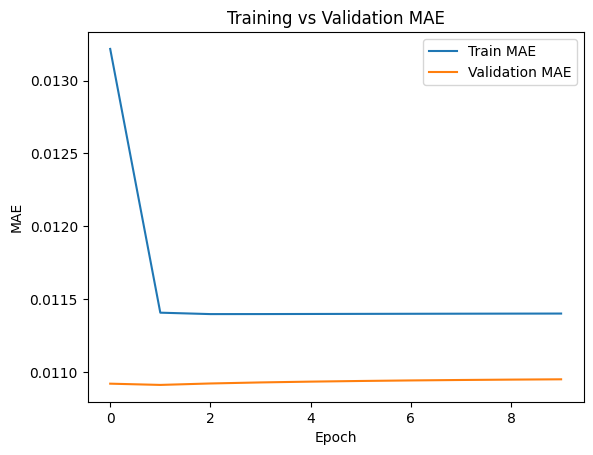

In [19]:
plot_learning_curves(history.history["loss"], history.history["val_loss"])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step


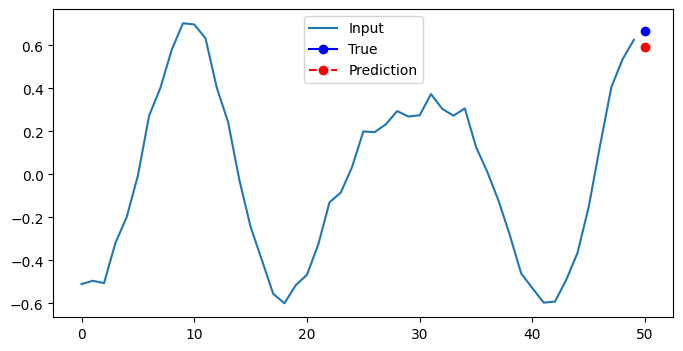

In [51]:
y_pred_simple = model.predict(X_test[1:2])
plot_series(X_test[1], y_test[1], y_pred_simple[0])
plt.show()

In [22]:
deep_RNN = keras.models.Sequential([
    keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.SimpleRNN(20),
    keras.layers.Dense(1)
])

deep_RNN.compile(loss="mse", optimizer="adam")

deep_history = deep_RNN.fit(X_train, y_train, epochs=10,
               validation_data=(X_valid, y_valid))

Epoch 1/10


c:\Users\beruk\DEEPLEARN-ING\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0270 - val_loss: 0.0056
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0046 - val_loss: 0.0038
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0036 - val_loss: 0.0033
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0033 - val_loss: 0.0031
Epoch 5/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0031 - val_loss: 0.0030
Epoch 6/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0031 - val_loss: 0.0029
Epoch 7/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0030 - val_loss: 0.0028
Epoch 8/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0030 - val_loss: 0.0028
Epoch 9/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0030 - val_loss: 0.0028
Epoch 10/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0030 - val_loss: 0.0027


In [26]:
deep_RNN.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_3 (SimpleRNN)        │ (None, None, 20)       │           440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_4 (SimpleRNN)        │ (None, 20)             │           820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,845 (15.02 KB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,564 (10.02 KB)

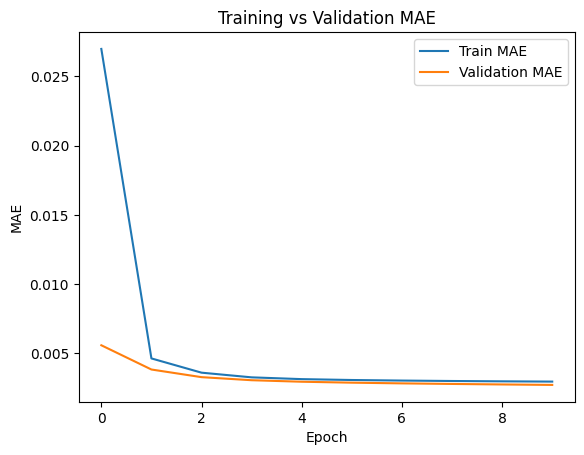

In [23]:
plot_learning_curves(deep_history.history["loss"], deep_history.history["val_loss"])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


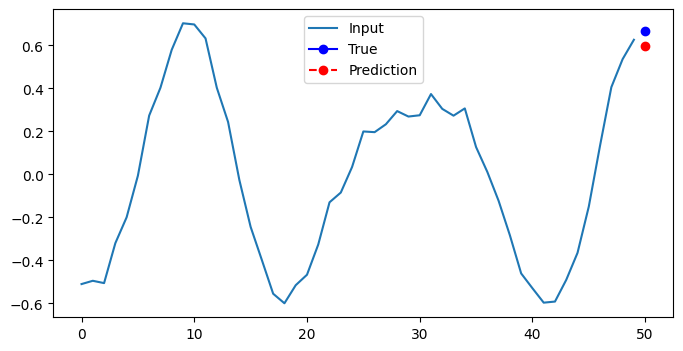

In [34]:
y_pred =deep_RNN.predict(X_test[1:2])

def plot_series(input_series, true_series=None, pred_series=None):
    plt.figure(figsize=(8,4))

    input_series = input_series.flatten()
    plt.plot(input_series, label="Input")

    n_input = len(input_series)

    if true_series is not None:
        true_series = true_series.flatten()
        plt.plot(range(n_input, n_input+len(true_series)),
                 true_series, "bo-", label="True")

    if pred_series is not None:
        pred_series = pred_series.flatten()
        plt.plot(range(n_input, n_input+len(pred_series)),
                 pred_series, "ro--", label="Prediction")

    plt.legend()
    plt.show()

plot_series(X_test[1], y_test[1], y_pred[0])
plt.show()

## Multi-step Forcasting 


In [54]:
ahead = 3

X_train, y_train = series[:7000, :n_steps-ahead], series[:7000,  n_steps-ahead:n_steps]
X_valid, y_valid = series[7000:9000, :n_steps-ahead], series[7000:9000,  n_steps-ahead:n_steps]
X_test, y_test = series[9000:, :n_steps-ahead], series[9000:,  n_steps-ahead:n_steps]

X_train.shape, y_train.shape

((7000, 47, 1), (7000, 3, 1))

In [39]:
deep_multi_RNN = keras.models.Sequential([
    keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.SimpleRNN(20),
    keras.layers.Dense(3)
])

deep_multi_RNN.compile(loss="mse", optimizer="adam")
depp_multi_history = deep_multi_RNN.fit(X_train, y_train, epochs=10,
               validation_data=(X_valid, y_valid))

Epoch 1/10


c:\Users\beruk\DEEPLEARN-ING\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0661 - val_loss: 0.0185
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0156 - val_loss: 0.0121
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0109 - val_loss: 0.0093
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0090 - val_loss: 0.0081
Epoch 5/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0081 - val_loss: 0.0074
Epoch 6/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0075 - val_loss: 0.0069
Epoch 7/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0070 - val_loss: 0.0068
Epoch 8/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0065 - val_loss: 0.0062
Epoch 9/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0060 - val_loss: 0.0060
Epoch 10/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0057 - val_loss: 0.0059


In [52]:
deep_multi_RNN.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_5 (SimpleRNN)        │ (None, None, 20)       │           440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_6 (SimpleRNN)        │ (None, 20)             │           820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            63 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,971 (15.52 KB)

 Trainable params: 1,323 (5.17 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,648 (10.35 KB)

## Learning Curve deep multi Forcaster

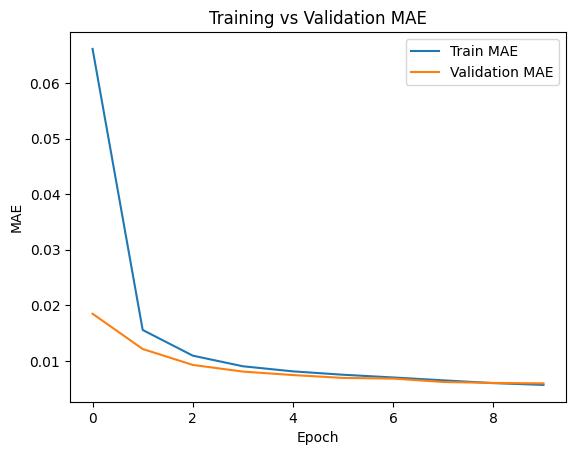

In [42]:
plot_learning_curves(depp_multi_history.history["loss"], depp_multi_history.history["val_loss"])

## prediction from deep Multi-step model

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step


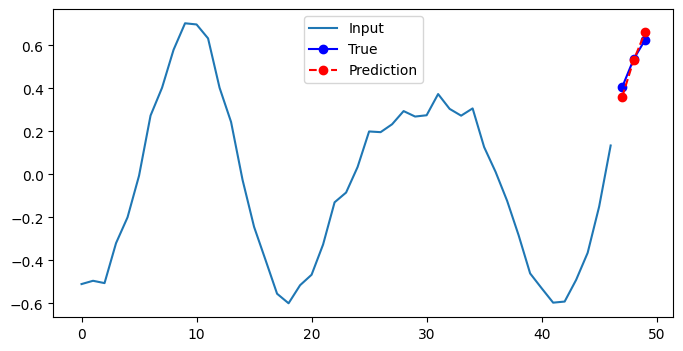

In [40]:
y_pred_multi = deep_multi_RNN.predict(X_test[1:2])
plot_series(X_test[1], y_test[1], y_pred_multi[0])
plt.show()

In [43]:
deep_multi_norm_RNN = keras.models.Sequential([
    keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.BatchNormalization(),

    keras.layers.SimpleRNN(20),
    keras.layers.BatchNormalization(),

    keras.layers.Dense(3)
])

deep_multi_norm_RNN.compile(loss="mse", optimizer="adam")
depp_multi_norm_history = deep_multi_norm_RNN.fit(X_train, y_train, epochs=10,
               validation_data=(X_valid, y_valid))

Epoch 1/10


c:\Users\beruk\DEEPLEARN-ING\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.1304 - val_loss: 0.0705
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0299 - val_loss: 0.0247
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0220 - val_loss: 0.0147
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0189 - val_loss: 0.0132
Epoch 5/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0174 - val_loss: 0.0123
Epoch 6/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0164 - val_loss: 0.0118
Epoch 7/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0157 - val_loss: 0.0113
Epoch 8/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0151 - val_loss: 0.0109
Epoch 9/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0147 - val_loss: 0.0105
Epoch 10/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0142 - val_loss: 0.0100


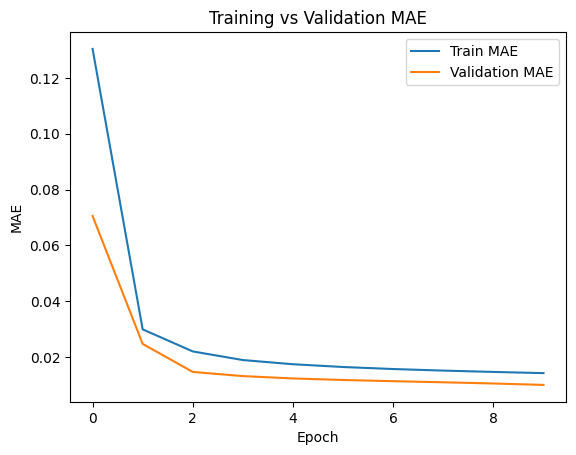

In [44]:
plot_learning_curves(depp_multi_norm_history.history["loss"], depp_multi_norm_history.history["val_loss"])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step


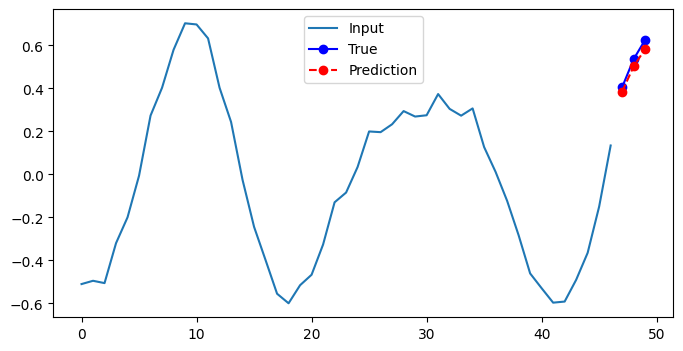

In [55]:
y_pred_multi = deep_multi_norm_RNN.predict(X_test[1:2])
plot_series(X_test[1], y_test[1], y_pred_multi[0])  
plt.show()

In [47]:
np.random.seed(42)
tf.random.set_seed(42)

Gru_multi_model = keras.models.Sequential([
    keras.layers.GRU(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.GRU(20),
    keras.layers.Dense(3)
])

Gru_multi_model.compile(loss="mse", optimizer="adam")
Gru_history = Gru_multi_model.fit(X_train, y_train.squeeze(-1), epochs=10,
                    validation_data=(X_valid, y_valid.squeeze(-1)))

Epoch 1/10


c:\Users\beruk\DEEPLEARN-ING\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


219/219 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - loss: 0.0542 - val_loss: 0.0279
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - loss: 0.0219 - val_loss: 0.0162
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - loss: 0.0134 - val_loss: 0.0118
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - loss: 0.0109 - val_loss: 0.0100
Epoch 5/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - loss: 0.0099 - val_loss: 0.0092
Epoch 6/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.0093 - val_loss: 0.0086
Epoch 7/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.0088 - val_loss: 0.0080
Epoch 8/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.0082 - val_loss: 0.0074
Epoch 9/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 0.0076 - val_loss: 0.0068
Epoch 10/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.0070 - val_loss: 0.0064


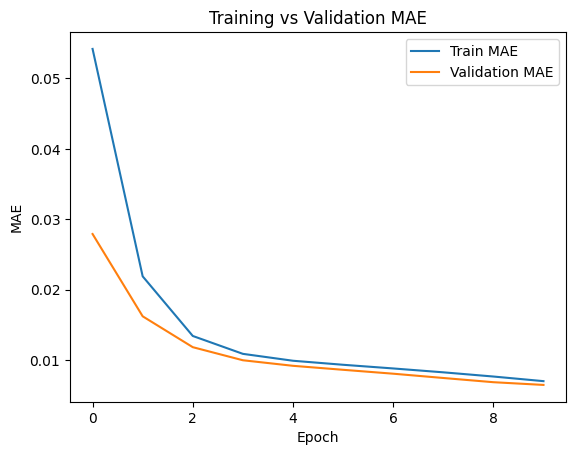

In [48]:
plot_learning_curves(Gru_history.history["loss"], Gru_history.history["val_loss"])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step


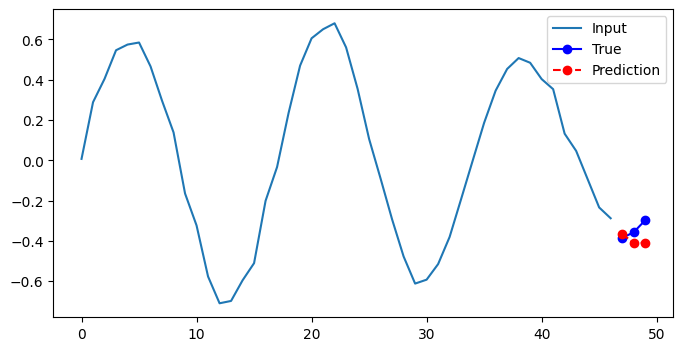

In [49]:
y_pred_gru = Gru_multi_model.predict(X_test[2:3])
plot_series(X_test[2], y_test[2], y_pred_gru[0])
plt.show()